# Prompt 4B2 - Benefit-Aware Selective Correction

**Adaptive Development Validation**

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
REPORTS = ROOT / 'outputs' / 'reports'
FIGURES = ROOT / 'outputs' / 'figures' / 'prompt4b2'
FIGURES.mkdir(parents=True, exist_ok=True)
display(Markdown('**Adaptive Development Validation - not a Final Test or IID result.**'))

**Adaptive Development Validation - not a Final Test or IID result.**

## 1. Objective

This notebook reports the bounded Prompt 4B2 experiment. Every result is Adaptive Development Validation, not an independent Test.

## 2. Prompt 4B handoff

This section uses saved Prompt 4B2 artifacts only.

In [2]:
display(pd.DataFrame([json.loads((REPORTS/'prompt4b2_preflight.json').read_text())]).drop(columns=['prediction_audit'], errors='ignore'))

,status,created_at_utc,development_sha256,train_rows,validation_rows,selection_rows,audit_rows,q90_train,cap25,feature_count,raw_access_count,iid_feature_access_count,iid_target_access_count,iid_prediction_count,final_freeze_absent,prompt4c_not_started
0,PASS,2026-08-07T00:22:21.994755+00:00,0ed232397be3ec4de1483c594954dce7b4704b375ca295...,400000,100000,70000,30000,438.0,109.5,35,0,0,0,0,True,True


## 3. Current Global/Stage 3 references

This section uses saved Prompt 4B2 artifacts only.

In [3]:
cross=pd.read_csv(REPORTS/'prompt4b2_cross_block_comparison.csv'); display(cross.loc[cross.reference.isin(['Global','Prompt 4B Stage 3'])])

,reference,candidate_id,selection_mae,audit_mae,complete_validation_mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,p85_to_p95_boundary_mae,top_decile_signed_error,top_decile_underprediction_rate,conditions_passed,provisional_status,number_of_fitted_inference_components,deployment_complexity
0,Global,ens_boost_cat060,62.519519,61.975508,62.356316,125.418232,47.576966,195.178575,279.352393,98.963799,-139.054319,0.793968,0,REFERENCE,1,one saved boosting ensemble
3,Prompt 4B Stage 3,stage3_residual_t75_a75,62.352823,61.832268,62.196656,123.038499,47.669010,192.756864,272.424700,100.338601,-127.335474,0.777290,5,PARTIAL,3,Global + Meta Gate + residual Specialist


## 4. Why routing remains the bottleneck

Saved Oracle evidence shows useful correction signal, but broad routing can damage Body rows. This stage asks when a fixed correction is likely to help.

## 5. Gate x Specialist 2x2 completion

This section uses saved Prompt 4B2 artifacts only.

In [4]:
factorial=pd.read_csv(REPORTS/'prompt4b2_blockA_factorial.csv'); display(factorial.loc[factorial.scope=='complete_validation'])

,factorial_cell,candidate_id,scope,mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,top_decile_signed_error,top_decile_underprediction_rate
2,Old Gate + Direct Specialist,stage1_raw_t85_a50_cap25,complete_validation,62.225680,124.160298,48.226291,188.038422,265.283314,-122.373991,0.753421
5,Meta Gate + Direct Specialist,stage2_meta_t65_a50_cap25,complete_validation,62.256033,124.576664,47.686675,193.191092,273.864460,-131.814235,0.780585
8,Meta Gate + Residual Specialist,stage3_residual_t75_a75,complete_validation,62.196656,123.038499,47.669010,192.756864,272.424700,-127.335474,0.777290
11,Old Gate + Residual Specialist,nf_oldraw_residual_symcap25,complete_validation,62.186676,123.745438,48.198036,187.902826,264.887624,-120.708291,0.752122


## 6. Positive-only correction

This section uses saved Prompt 4B2 artifacts only.

In [5]:
blockA=pd.read_csv(REPORTS/'prompt4b2_blockA_candidates.csv'); display(blockA.loc[blockA.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]).head(9))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
26,nf_global2_oldraw_direct_cap25,Block A,complete_validation,100000,62.114739,124.433887,0.700015,0.386188,36.699948,132.703985,...,0.483705,True,True,False,True,True,True,5,6,PARTIAL
2,nf_oldraw_residual_symcap25,Block A,complete_validation,100000,62.186676,123.745438,0.703325,0.390791,36.771252,132.825903,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
8,nf_oldraw_residual_positive_cap25,Block A,complete_validation,100000,62.193864,123.746372,0.703321,0.390798,36.783631,132.864755,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
11,nf_meta_residual_positive_cap25,Block A,complete_validation,100000,62.235112,124.124260,0.701506,0.390767,36.785118,132.771876,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
14,nf_consensus_residual_positive_cap25,Block A,complete_validation,100000,62.240779,124.191977,0.701181,0.390757,36.797054,132.784281,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
17,nf_meta_residual_positive_gamma15,Block A,complete_validation,100000,62.249230,124.230193,0.700997,0.390771,36.806782,132.717606,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
20,nf_meta_residual_positive_gamma20,Block A,complete_validation,100000,62.260003,124.309439,0.700615,0.390777,36.801900,132.663211,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
5,nf_oldplatt_residual,Block A,complete_validation,100000,62.212362,123.605328,0.703997,0.390733,36.793645,132.780496,...,0.475518,True,False,False,True,True,True,4,6,PARTIAL
23,nf_global_convex_boosting_deep,Block A,complete_validation,100000,62.263797,125.829968,0.693246,0.386208,36.751796,132.422939,...,0.484638,True,False,True,False,False,False,2,6,PARTIAL


## 7. Consensus routing

This section uses saved Prompt 4B2 artifacts only.

In [6]:
blockA=pd.read_csv(REPORTS/'prompt4b2_blockA_candidates.csv'); display(blockA.loc[blockA.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]).head(9))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
26,nf_global2_oldraw_direct_cap25,Block A,complete_validation,100000,62.114739,124.433887,0.700015,0.386188,36.699948,132.703985,...,0.483705,True,True,False,True,True,True,5,6,PARTIAL
2,nf_oldraw_residual_symcap25,Block A,complete_validation,100000,62.186676,123.745438,0.703325,0.390791,36.771252,132.825903,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
8,nf_oldraw_residual_positive_cap25,Block A,complete_validation,100000,62.193864,123.746372,0.703321,0.390798,36.783631,132.864755,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
11,nf_meta_residual_positive_cap25,Block A,complete_validation,100000,62.235112,124.124260,0.701506,0.390767,36.785118,132.771876,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
14,nf_consensus_residual_positive_cap25,Block A,complete_validation,100000,62.240779,124.191977,0.701181,0.390757,36.797054,132.784281,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
17,nf_meta_residual_positive_gamma15,Block A,complete_validation,100000,62.249230,124.230193,0.700997,0.390771,36.806782,132.717606,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
20,nf_meta_residual_positive_gamma20,Block A,complete_validation,100000,62.260003,124.309439,0.700615,0.390777,36.801900,132.663211,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
5,nf_oldplatt_residual,Block A,complete_validation,100000,62.212362,123.605328,0.703997,0.390733,36.793645,132.780496,...,0.475518,True,False,False,True,True,True,4,6,PARTIAL
23,nf_global_convex_boosting_deep,Block A,complete_validation,100000,62.263797,125.829968,0.693246,0.386208,36.751796,132.422939,...,0.484638,True,False,True,False,False,False,2,6,PARTIAL


## 8. Nonlinear confidence

This section uses saved Prompt 4B2 artifacts only.

In [7]:
blockA=pd.read_csv(REPORTS/'prompt4b2_blockA_candidates.csv'); display(blockA.loc[blockA.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]).head(9))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
26,nf_global2_oldraw_direct_cap25,Block A,complete_validation,100000,62.114739,124.433887,0.700015,0.386188,36.699948,132.703985,...,0.483705,True,True,False,True,True,True,5,6,PARTIAL
2,nf_oldraw_residual_symcap25,Block A,complete_validation,100000,62.186676,123.745438,0.703325,0.390791,36.771252,132.825903,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
8,nf_oldraw_residual_positive_cap25,Block A,complete_validation,100000,62.193864,123.746372,0.703321,0.390798,36.783631,132.864755,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
11,nf_meta_residual_positive_cap25,Block A,complete_validation,100000,62.235112,124.124260,0.701506,0.390767,36.785118,132.771876,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
14,nf_consensus_residual_positive_cap25,Block A,complete_validation,100000,62.240779,124.191977,0.701181,0.390757,36.797054,132.784281,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
17,nf_meta_residual_positive_gamma15,Block A,complete_validation,100000,62.249230,124.230193,0.700997,0.390771,36.806782,132.717606,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
20,nf_meta_residual_positive_gamma20,Block A,complete_validation,100000,62.260003,124.309439,0.700615,0.390777,36.801900,132.663211,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
5,nf_oldplatt_residual,Block A,complete_validation,100000,62.212362,123.605328,0.703997,0.390733,36.793645,132.780496,...,0.475518,True,False,False,True,True,True,4,6,PARTIAL
23,nf_global_convex_boosting_deep,Block A,complete_validation,100000,62.263797,125.829968,0.693246,0.386208,36.751796,132.422939,...,0.484638,True,False,True,False,False,False,2,6,PARTIAL


## 9. Stronger static Global

This section uses saved Prompt 4B2 artifacts only.

In [8]:
blockA=pd.read_csv(REPORTS/'prompt4b2_blockA_candidates.csv'); display(blockA.loc[blockA.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]).head(9))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
26,nf_global2_oldraw_direct_cap25,Block A,complete_validation,100000,62.114739,124.433887,0.700015,0.386188,36.699948,132.703985,...,0.483705,True,True,False,True,True,True,5,6,PARTIAL
2,nf_oldraw_residual_symcap25,Block A,complete_validation,100000,62.186676,123.745438,0.703325,0.390791,36.771252,132.825903,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
8,nf_oldraw_residual_positive_cap25,Block A,complete_validation,100000,62.193864,123.746372,0.703321,0.390798,36.783631,132.864755,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
11,nf_meta_residual_positive_cap25,Block A,complete_validation,100000,62.235112,124.124260,0.701506,0.390767,36.785118,132.771876,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
14,nf_consensus_residual_positive_cap25,Block A,complete_validation,100000,62.240779,124.191977,0.701181,0.390757,36.797054,132.784281,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
17,nf_meta_residual_positive_gamma15,Block A,complete_validation,100000,62.249230,124.230193,0.700997,0.390771,36.806782,132.717606,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
20,nf_meta_residual_positive_gamma20,Block A,complete_validation,100000,62.260003,124.309439,0.700615,0.390777,36.801900,132.663211,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
5,nf_oldplatt_residual,Block A,complete_validation,100000,62.212362,123.605328,0.703997,0.390733,36.793645,132.780496,...,0.475518,True,False,False,True,True,True,4,6,PARTIAL
23,nf_global_convex_boosting_deep,Block A,complete_validation,100000,62.263797,125.829968,0.693246,0.386208,36.751796,132.422939,...,0.484638,True,False,True,False,False,False,2,6,PARTIAL


## 10. Block A result

This section uses saved Prompt 4B2 artifacts only.

In [9]:
blockA=pd.read_csv(REPORTS/'prompt4b2_blockA_candidates.csv'); display(blockA.loc[blockA.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]).head(9))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
26,nf_global2_oldraw_direct_cap25,Block A,complete_validation,100000,62.114739,124.433887,0.700015,0.386188,36.699948,132.703985,...,0.483705,True,True,False,True,True,True,5,6,PARTIAL
2,nf_oldraw_residual_symcap25,Block A,complete_validation,100000,62.186676,123.745438,0.703325,0.390791,36.771252,132.825903,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
8,nf_oldraw_residual_positive_cap25,Block A,complete_validation,100000,62.193864,123.746372,0.703321,0.390798,36.783631,132.864755,...,0.474652,True,True,False,True,True,True,5,6,PARTIAL
11,nf_meta_residual_positive_cap25,Block A,complete_validation,100000,62.235112,124.124260,0.701506,0.390767,36.785118,132.771876,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
14,nf_consensus_residual_positive_cap25,Block A,complete_validation,100000,62.240779,124.191977,0.701181,0.390757,36.797054,132.784281,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
17,nf_meta_residual_positive_gamma15,Block A,complete_validation,100000,62.249230,124.230193,0.700997,0.390771,36.806782,132.717606,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
20,nf_meta_residual_positive_gamma20,Block A,complete_validation,100000,62.260003,124.309439,0.700615,0.390777,36.801900,132.663211,...,0.475529,True,False,True,True,True,True,5,6,PARTIAL
5,nf_oldplatt_residual,Block A,complete_validation,100000,62.212362,123.605328,0.703997,0.390733,36.793645,132.780496,...,0.475518,True,False,False,True,True,True,4,6,PARTIAL
23,nf_global_convex_boosting_deep,Block A,complete_validation,100000,62.263797,125.829968,0.693246,0.386208,36.751796,132.422939,...,0.484638,True,False,True,False,False,False,2,6,PARTIAL


## 11. Residual underprediction diagnosis

This section uses saved Prompt 4B2 artifacts only.

## 12. Quantile Residual design

This section uses saved Prompt 4B2 artifacts only.

## 13. q60/q65 diagnostics

This section uses saved Prompt 4B2 artifacts only.

,model_id,loss,rows,residual_mae,residual_rmse,residual_signed_error,median_residual_error,positive_correction_rate,predicted_true_residual_correlation,correct_correction_direction,p90_absolute_residual_error,reused
0,mae_residual_stage3,MAE,9974,143.128753,288.864228,-33.212209,1.873826,0.957088,0.362556,0.797173,326.926789,NaN
1,quantile_residual_q60,Quantile:alpha=0.60,9974,148.757867,283.326880,13.415094,28.023608,0.996090,0.383749,0.794666,341.941738,False
2,quantile_residual_q65,Quantile:alpha=0.65,9974,155.793257,289.664782,39.407443,41.615524,0.998997,0.358169,0.794365,352.250804,False


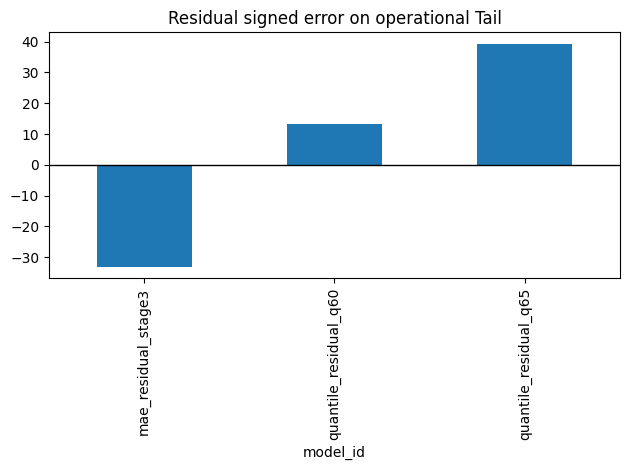

In [10]:
diag=pd.read_csv(REPORTS/'prompt4b2_blockB_residual_diagnostics.csv'); display(diag); ax=diag.plot.bar(x='model_id',y='residual_signed_error',legend=False,title='Residual signed error on operational Tail'); ax.axhline(0,color='black',lw=1); plt.tight_layout(); plt.savefig(FIGURES/'quantile_signed_error.png',dpi=130); plt.show()

## 14. Quantile routing results

This section uses saved Prompt 4B2 artifacts only.

In [11]:
blockB=pd.read_csv(REPORTS/'prompt4b2_blockB_candidates.csv'); display(blockB.loc[blockB.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
2,quantile_q60_meta_symmetric,Block B,complete_validation,100000,62.292177,121.838785,0.712397,0.390969,36.843463,132.988811,...,0.475529,True,False,False,True,True,True,4,6,PARTIAL
5,quantile_q60_meta_positive_cap25,Block B,complete_validation,100000,62.321663,124.046352,0.701881,0.390931,36.836567,133.007426,...,0.475529,True,False,False,True,True,True,4,6,PARTIAL
11,quantile_q65_meta_positive_cap25,Block B,complete_validation,100000,62.380958,124.099074,0.701627,0.391032,36.860357,133.186272,...,0.475529,False,False,False,True,True,True,3,6,PARTIAL
8,quantile_q65_meta_symmetric,Block B,complete_validation,100000,62.442754,122.070662,0.711302,0.391224,36.858337,133.200363,...,0.475529,False,False,False,True,True,True,3,6,PARTIAL


## 15. Block B result

This section uses saved Prompt 4B2 artifacts only.

In [12]:
blockB=pd.read_csv(REPORTS/'prompt4b2_blockB_candidates.csv'); display(blockB.loc[blockB.scope=='complete_validation'].sort_values(['conditions_passed','mae'],ascending=[False,True]))

,candidate_id,block,scope,n_rows,mae,rmse,r2,rmsle,median_absolute_error,p90_absolute_error,...,operational_body_underprediction_rate,complete_mae_lower,top_decile_mae_improves_3pct,bottom_90_mae_worsens_at_most_0_25pct,rmse_worsens_at_most_0_25pct,top_decile_signed_error_closer_to_zero,top_decile_underprediction_rate_decreases,conditions_passed,conditions_total,provisional_acceptance_status
2,quantile_q60_meta_symmetric,Block B,complete_validation,100000,62.292177,121.838785,0.712397,0.390969,36.843463,132.988811,...,0.475529,True,False,False,True,True,True,4,6,PARTIAL
5,quantile_q60_meta_positive_cap25,Block B,complete_validation,100000,62.321663,124.046352,0.701881,0.390931,36.836567,133.007426,...,0.475529,True,False,False,True,True,True,4,6,PARTIAL
11,quantile_q65_meta_positive_cap25,Block B,complete_validation,100000,62.380958,124.099074,0.701627,0.391032,36.860357,133.186272,...,0.475529,False,False,False,True,True,True,3,6,PARTIAL
8,quantile_q65_meta_symmetric,Block B,complete_validation,100000,62.442754,122.070662,0.711302,0.391224,36.858337,133.200363,...,0.475529,False,False,False,True,True,True,3,6,PARTIAL


## 16. OOF Residual construction

This section uses saved Prompt 4B2 artifacts only.

In [13]:
display(pd.DataFrame([json.loads((REPORTS/'prompt4b2_blockC_report.json').read_text())['oof_residual']]))

,rows,exactly_one_oof_per_train_row,zero_self_fit_rows,finite,foldA_reused,foldB_reused
0,400000,True,0,True,True,True


## 17. Benefit target definition

This section uses saved Prompt 4B2 artifacts only.

## 18. Benefit target distribution

This section uses saved Prompt 4B2 artifacts only.

,benefit_oof
count,400000.000000
mean,-57.636727
std,70.477452
min,-109.500000
25%,-109.500000
50%,-98.280526
75%,-22.566046
max,109.500000


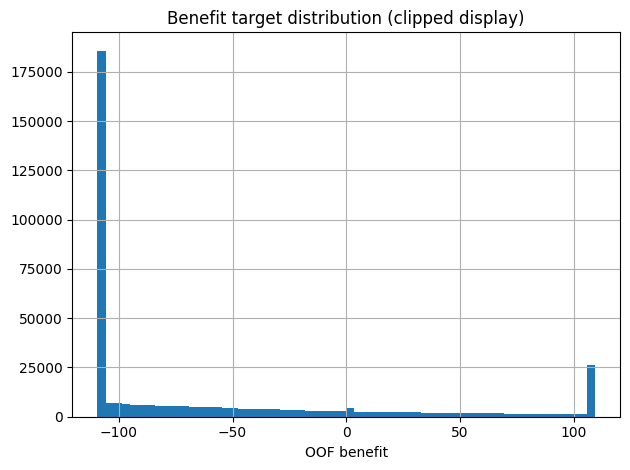

In [14]:
benefit=pd.read_parquet(ROOT/'outputs/predictions/prompt4b2/train/benefit_training_table.parquet'); display(benefit.benefit_oof.describe().to_frame()); benefit.benefit_oof.clip(-150,150).hist(bins=60); plt.title('Benefit target distribution (clipped display)'); plt.xlabel('OOF benefit'); plt.tight_layout(); plt.savefig(FIGURES/'benefit_histogram.png',dpi=130); plt.show()

## 19. Benefit Router design

This section uses saved Prompt 4B2 artifacts only.

## 20. Benefit Router quality

This section uses saved Prompt 4B2 artifacts only.

In [15]:
router=pd.read_csv(REPORTS/'prompt4b2_blockC_router_metrics.csv'); display(router); valid=pd.read_parquet(ROOT/'outputs/predictions/prompt4b2/validation/benefit_b0.parquet'); sample=valid.iloc[::20]; plt.scatter(sample.predicted_benefit,sample.realized_benefit,s=5,alpha=.25); plt.axhline(0,color='black',lw=1); plt.xlabel('Predicted benefit'); plt.ylabel('Realized benefit'); plt.tight_layout(); plt.savefig(FIGURES/'predicted_vs_realized_benefit.png',dpi=130); plt.show()

## 21. Realized gain/loss of routed rows

This section uses saved Prompt 4B2 artifacts only.

,candidate_id,block,scope,benefit_threshold,n_rows,mae,rmse,r2,rmsle,median_absolute_error,...,mean_realized_benefit_selected,mean_realized_damage_harmful_selected,tail_proportion_selected,precision_realized_benefit_positive,recall_realized_benefit_positive,overall_mae,body_mae,top_decile_mae_router,top_five_percent_mae_router,rmse_router
2,benefit_b0,Block C,complete_validation,0.0,100000,62.231450,124.382868,0.700261,0.390781,36.790170,...,5.586826,57.536997,0.908725,0.483669,0.054458,62.231450,47.707276,192.929848,272.367190,124.382868
5,benefit_b5,Block C,complete_validation,5.0,100000,62.281765,124.620599,0.699114,0.390750,36.824810,...,9.940018,67.754974,0.918667,0.529333,0.020000,62.281765,47.627587,194.148824,276.499920,124.620599
8,benefit_b10,Block C,complete_validation,10.0,100000,62.312712,125.013030,0.697216,0.390769,36.819579,...,22.360766,85.505421,0.912821,0.620513,0.006096,62.312712,47.605389,194.657469,278.174493,125.013030


,candidate_id,selected_row_percentage,precision_realized_benefit_positive
2,benefit_b0,2.235,0.483669
5,benefit_b5,0.750,0.529333
8,benefit_b10,0.195,0.620513


,router_id,selected_rows,selected_percentage,positive_benefit_precision,positive_benefit_recall,mean_realized_benefit_selected,comparison_proposal
0,old_tail_gate_t85,10169,10.169,0.426099,0.218287,-7.332352,"clip(max(full Stage 3 residual,0),0,cap25)"
1,meta_tail_gate_t75,4583,4.583,0.452106,0.104383,1.618145,"clip(max(full Stage 3 residual,0),0,cap25)"
2,benefit_b0,2235,2.235,0.483669,0.054458,5.586826,"clip(max(full Stage 3 residual,0),0,cap25)"
3,benefit_b5,750,0.750,0.529333,0.020000,9.940018,"clip(max(full Stage 3 residual,0),0,cap25)"
4,benefit_b10,195,0.195,0.620513,0.006096,22.360766,"clip(max(full Stage 3 residual,0),0,cap25)"


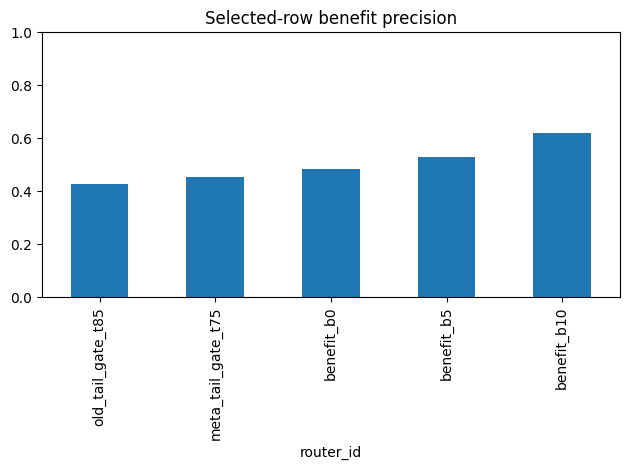

In [16]:
blockC=pd.read_csv(REPORTS/'prompt4b2_blockC_candidates.csv'); display(blockC.loc[blockC.scope=='complete_validation'].sort_values('mae')); ifcols=[c for c in ['candidate_id','selected_row_percentage','precision_realized_benefit_positive'] if c in blockC.columns]; display(blockC.loc[blockC.scope=='complete_validation',ifcols]); precision=pd.read_csv(REPORTS/'prompt4b2_router_precision_comparison.csv'); display(precision); precision.plot.bar(x='router_id',y='positive_benefit_precision',legend=False,title='Selected-row benefit precision'); plt.ylim(0,1); plt.tight_layout(); plt.savefig(FIGURES/'selected_benefit_precision.png',dpi=130); plt.show()

## 22. Benefit routing results

This section uses saved Prompt 4B2 artifacts only.

In [17]:
blockC=pd.read_csv(REPORTS/'prompt4b2_blockC_candidates.csv'); display(blockC.loc[blockC.scope=='complete_validation'].sort_values('mae')); ifcols=[c for c in ['candidate_id','selected_row_percentage','precision_realized_benefit_positive'] if c in blockC.columns]; display(blockC.loc[blockC.scope=='complete_validation',ifcols])

,candidate_id,block,scope,benefit_threshold,n_rows,mae,rmse,r2,rmsle,median_absolute_error,...,mean_realized_benefit_selected,mean_realized_damage_harmful_selected,tail_proportion_selected,precision_realized_benefit_positive,recall_realized_benefit_positive,overall_mae,body_mae,top_decile_mae_router,top_five_percent_mae_router,rmse_router
2,benefit_b0,Block C,complete_validation,0.0,100000,62.231450,124.382868,0.700261,0.390781,36.790170,...,5.586826,57.536997,0.908725,0.483669,0.054458,62.231450,47.707276,192.929848,272.367190,124.382868
5,benefit_b5,Block C,complete_validation,5.0,100000,62.281765,124.620599,0.699114,0.390750,36.824810,...,9.940018,67.754974,0.918667,0.529333,0.020000,62.281765,47.627587,194.148824,276.499920,124.620599
8,benefit_b10,Block C,complete_validation,10.0,100000,62.312712,125.013030,0.697216,0.390769,36.819579,...,22.360766,85.505421,0.912821,0.620513,0.006096,62.312712,47.605389,194.657469,278.174493,125.013030


,candidate_id,selected_row_percentage,precision_realized_benefit_positive
2,benefit_b0,2.235,0.483669
5,benefit_b5,0.750,0.529333
8,benefit_b10,0.195,0.620513


## 23. Block C result

This section uses saved Prompt 4B2 artifacts only.

In [18]:
blockC=pd.read_csv(REPORTS/'prompt4b2_blockC_candidates.csv'); display(blockC.loc[blockC.scope=='complete_validation'].sort_values('mae')); ifcols=[c for c in ['candidate_id','selected_row_percentage','precision_realized_benefit_positive'] if c in blockC.columns]; display(blockC.loc[blockC.scope=='complete_validation',ifcols])

,candidate_id,block,scope,benefit_threshold,n_rows,mae,rmse,r2,rmsle,median_absolute_error,...,mean_realized_benefit_selected,mean_realized_damage_harmful_selected,tail_proportion_selected,precision_realized_benefit_positive,recall_realized_benefit_positive,overall_mae,body_mae,top_decile_mae_router,top_five_percent_mae_router,rmse_router
2,benefit_b0,Block C,complete_validation,0.0,100000,62.231450,124.382868,0.700261,0.390781,36.790170,...,5.586826,57.536997,0.908725,0.483669,0.054458,62.231450,47.707276,192.929848,272.367190,124.382868
5,benefit_b5,Block C,complete_validation,5.0,100000,62.281765,124.620599,0.699114,0.390750,36.824810,...,9.940018,67.754974,0.918667,0.529333,0.020000,62.281765,47.627587,194.148824,276.499920,124.620599
8,benefit_b10,Block C,complete_validation,10.0,100000,62.312712,125.013030,0.697216,0.390769,36.819579,...,22.360766,85.505421,0.912821,0.620513,0.006096,62.312712,47.605389,194.657469,278.174493,125.013030


,candidate_id,selected_row_percentage,precision_realized_benefit_positive
2,benefit_b0,2.235,0.483669
5,benefit_b5,0.750,0.529333
8,benefit_b10,0.195,0.620513


## 24. Cross-block leaderboard

This section uses saved Prompt 4B2 artifacts only.

In [19]:
display(cross.sort_values(['conditions_passed','complete_validation_mae'],ascending=[False,True]))

,reference,candidate_id,selection_mae,audit_mae,complete_validation_mae,rmse,bottom_90_mae,top_decile_mae,top_five_percent_mae,p85_to_p95_boundary_mae,top_decile_signed_error,top_decile_underprediction_rate,conditions_passed,provisional_status,number_of_fitted_inference_components,deployment_complexity
4,Block A,nf_global2_oldraw_direct_cap25,62.249933,61.799286,62.114739,124.433887,47.969818,189.235379,266.861715,101.912247,-125.803946,0.761710,5,PARTIAL,3,saved components; zero new fits
3,Prompt 4B Stage 3,stage3_residual_t75_a75,62.352823,61.832268,62.196656,123.038499,47.669010,192.756864,272.424700,100.338601,-127.335474,0.777290,5,PARTIAL,3,Global + Meta Gate + residual Specialist
2,Prompt 4B Stage 1,stage1_raw_t85_a50_cap25,62.366821,61.896350,62.225680,124.160298,48.226291,188.038422,265.283314,101.102198,-122.373991,0.753421,5,PARTIAL,3,Global + old Gate + direct Specialist
6,Block C,benefit_b0,62.375994,61.894181,62.231450,124.382868,47.688426,192.929848,272.367190,100.614823,-127.857456,0.775392,5,PARTIAL,3,Global + residual proposal + Benefit Router
5,Block B,quantile_q60_meta_symmetric,62.446862,61.931244,62.292177,121.838785,47.770520,192.798549,269.714016,102.145644,-112.280671,0.759013,4,PARTIAL,3,Global + Meta Gate + Quantile residual
7,Prompt 4A aggressive Soft,soft_global_best_ensemble_a050,63.906354,63.545020,63.797954,124.748176,51.913643,170.602461,250.567117,86.464834,-99.799143,0.716668,4,PARTIAL,3,Global + old Gate + direct Specialist
1,Convex Deep Global,ens_convex_boosting_deep,62.415881,61.908934,62.263797,125.829968,47.291129,196.823415,281.664308,99.774892,-143.995008,0.803655,2,PARTIAL,1,one saved static ensemble
0,Global,ens_boost_cat060,62.519519,61.975508,62.356316,125.418232,47.576966,195.178575,279.352393,98.963799,-139.054319,0.793968,0,REFERENCE,1,one saved boosting ensemble


## 25. Body/Tail frontier

This section uses saved Prompt 4B2 artifacts only.

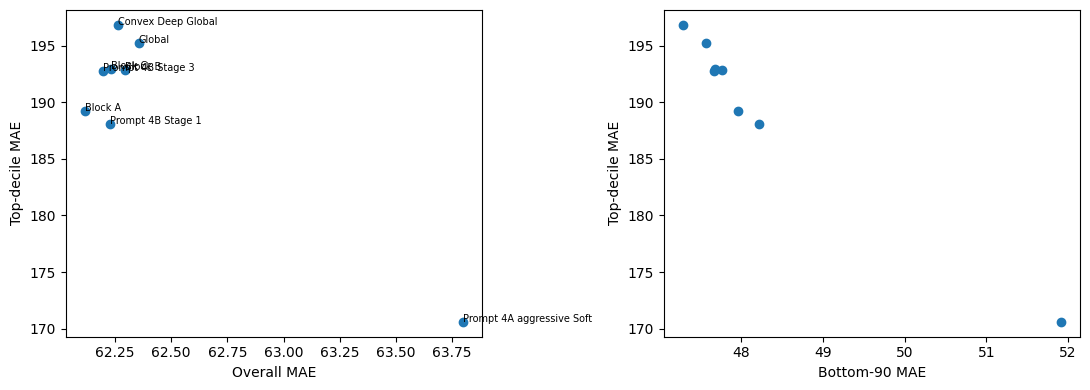

In [20]:
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].scatter(cross.complete_validation_mae,cross.top_decile_mae); axes[1].scatter(cross.bottom_90_mae,cross.top_decile_mae); [axes[0].annotate(r.reference,(r.complete_validation_mae,r.top_decile_mae),fontsize=7) for _,r in cross.iterrows()]; axes[0].set(xlabel='Overall MAE',ylabel='Top-decile MAE'); axes[1].set(xlabel='Bottom-90 MAE',ylabel='Top-decile MAE'); plt.tight_layout(); plt.savefig(FIGURES/'body_tail_frontiers.png',dpi=130); plt.show()

## 26. Top-5 analysis

This section uses saved Prompt 4B2 artifacts only.

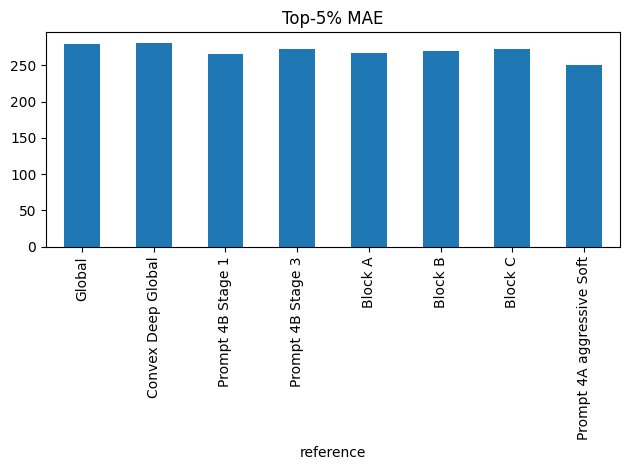

In [21]:
cross.plot.bar(x='reference',y='top_five_percent_mae',legend=False,title='Top-5% MAE'); plt.tight_layout(); plt.savefig(FIGURES/'top5_comparison.png',dpi=130); plt.show()

## 27. Signed-error analysis

This section uses saved Prompt 4B2 artifacts only.

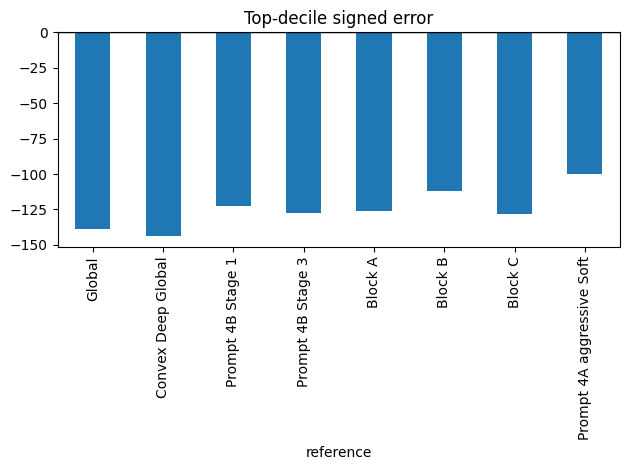

In [22]:
cross.plot.bar(x='reference',y='top_decile_signed_error',legend=False,title='Top-decile signed error'); plt.axhline(0,color='black',lw=1); plt.tight_layout(); plt.savefig(FIGURES/'signed_error.png',dpi=130); plt.show()

## 28. Bootstrap

This section uses saved Prompt 4B2 artifacts only.

In [23]:
boot=json.loads((REPORTS/'prompt4b2_bootstrap.json').read_text()); display(pd.json_normalize(boot['comparisons']))

,block,candidate_id,reference_id,resamples,seed,difference_definition,adaptive_development_limitation,overall_mae_difference.mean_difference,overall_mae_difference.median_difference,overall_mae_difference.percentile_2_5,overall_mae_difference.percentile_97_5,overall_mae_difference.win_proportion,fixed_complete_validation_top_decile_mae_difference.mean_difference,fixed_complete_validation_top_decile_mae_difference.median_difference,fixed_complete_validation_top_decile_mae_difference.percentile_2_5,fixed_complete_validation_top_decile_mae_difference.percentile_97_5,fixed_complete_validation_top_decile_mae_difference.win_proportion
0,A,nf_global2_oldraw_direct_cap25,ens_boost_cat060,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,-0.241391,-0.240698,-0.300691,-0.177352,1.000,-5.969505,-5.986226,-6.499358,-5.435069,1.000
1,A,nf_global2_oldraw_direct_cap25,stage3_residual_t75_a75,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,-0.082302,-0.081796,-0.174097,0.013611,0.954,-3.544642,-3.541742,-4.298802,-2.715852,1.000
2,B,quantile_q60_meta_symmetric,ens_boost_cat060,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,-0.061724,-0.060403,-0.196429,0.078501,0.806,-2.393262,-2.382596,-3.812228,-1.063539,0.998
3,B,quantile_q60_meta_symmetric,stage3_residual_t75_a75,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,0.097364,0.096814,0.025671,0.171710,0.008,0.031601,0.039746,-0.770726,0.795727,0.456
4,C,benefit_b0,ens_boost_cat060,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,-0.123666,-0.123331,-0.180983,-0.063992,1.000,-2.254486,-2.246625,-2.775822,-1.714355,1.000
5,C,benefit_b0,stage3_residual_t75_a75,500,42,candidate MAE minus reference MAE; negative fa...,Descriptive only; the interval does not remove...,0.035423,0.037918,-0.027798,0.096704,0.140,0.170377,0.163332,-0.413872,0.758153,0.274


## 29. Complexity comparison

This section uses saved Prompt 4B2 artifacts only.

In [24]:
display(cross[['reference','candidate_id','number_of_fitted_inference_components','deployment_complexity']])

,reference,candidate_id,number_of_fitted_inference_components,deployment_complexity
0,Global,ens_boost_cat060,1,one saved boosting ensemble
1,Convex Deep Global,ens_convex_boosting_deep,1,one saved static ensemble
2,Prompt 4B Stage 1,stage1_raw_t85_a50_cap25,3,Global + old Gate + direct Specialist
3,Prompt 4B Stage 3,stage3_residual_t75_a75,3,Global + Meta Gate + residual Specialist
4,Block A,nf_global2_oldraw_direct_cap25,3,saved components; zero new fits
5,Block B,quantile_q60_meta_symmetric,3,Global + Meta Gate + Quantile residual
6,Block C,benefit_b0,3,Global + residual proposal + Benefit Router
7,Prompt 4A aggressive Soft,soft_global_best_ensemble_a050,3,Global + old Gate + direct Specialist


## 30. Limitations

Selection, Audit, and complete Validation have all informed adaptive work. Bootstrap intervals are descriptive and do not remove adaptive-selection bias.

## 31. Human-review handoff to Prompt 4C

These experimental champions are references only. No final project model is selected or frozen. Human review is required before Prompt 4C.